# TTFT vs. Inter-Cluster I/O: Mismatched-Partition Disaggregation

**Question:** when prefill and decode clusters use *different* partitions (the prefill side picks a partition that suits its compute profile; the decode side picks one that suits generation), how does inter-cluster I/O (bandwidth and startup α) shape TTFT? When is disaggregation with a mismatched prefill partition actually *worth* the handoff cost?

**Method:**

- **Decode partition is fixed** at the decode-Pareto winner for GPT-1.8T MoE on GB200 NVL72: `PP=8 TP=8 EP=1 SP=1`.
- **Prefill partition is a choice variable**. Each scenario is named to make the mismatch axis explicit:
  - **Co-lo (matched reference)** — prefill partition = decode partition; no handoff.
  - **Mismatch A — *wide-TP prefill*** (`PP=1 TP=16 EP=4`): PP/TP/EP **all differ** from decode. Compute-biased prefill — a radically different partition that trades pipeline depth for wider TP.
  - **Mismatch B — *MoE-EP prefill*** (`PP=2 TP=8 EP=4`): PP and EP differ; **TP matches** decode. A subtler mismatch — reshuffle is needed (PP and EP both differ) but the compute shape is closer to co-lo.
- **KV handoff**: `DisaggSpec` with `disaggregated=True`, `inter_bandwidth_GBps` (swept) and `inter_alpha_us` (swept). Decode-side repack at GB200 scale-up BW (900 GB/s) with `repack_eta = 1.5` to capture the partition-reshuffle tax.
- **Sweep axes:**
  - `S_input ∈ {2k, 4k, 8k, 16k, 32k}` — prompt length (plot X-axis). This covers the realistic commercial workload band; production LLM serving papers (Splitwise, DistServe, SARATHI-Serve, Mooncake) report median prompts in the 1–8k range with long-context/agentic workloads pushing into the 16–32k+ tail.
  - **Panel 1**: `BW_inter` swept at fixed α. Tests the bandwidth-limited regime (KV volume ∝ S, so long prompts expose BW).
  - **Panel 2**: `α_inter` swept at fixed BW. Tests the small-message regime (α dominates when M_KV is tiny).
- Co-lo reference line overlaid as dashed black on both panels.

**Workload anchors per `S_input`** (rough mapping, with references):

| S_input | Typical workload | Anchor |
|---|---|---|
| **2k** | Chat / Q&A with short history | ShareGPT median; LMSys Arena |
| **4k** | Code assist, simple RAG | Copilot, basic retrieval |
| **8k** | Production assistant + multi-turn + RAG | Splitwise (Patel, ISCA '24); DistServe (Zhong, OSDI '24) |
| **16k** | Long-doc chat, multi-doc RAG | LongBench (Bai '24); production long-context tier |
| **32k** | Reasoning / agentic / long-context tasks | Mooncake (Qin '24) mean ≈ 7k, P99 → 100k+; InfiniteBench |

**Thesis to test:** at long prompts the mismatched prefill partition can beat co-lo *if* inter-cluster BW is high enough to hide the KV transfer; at low BW the handoff eats the prefill savings. α matters only at short prompts where M_KV is tiny.

## 1. Imports and spec loading

In [1]:
from __future__ import annotations

from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

from llm_perf import InferenceCalculator
from llm_perf.calculators.e2e_calculator import E2ECalculator
from llm_perf.calculators.prefill_calculator import PrefillCalculator
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.disagg_spec import DisaggSpec
from llm_perf.specs.overhead_spec import OverheadSpec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

BPP_FP4 = 0.5
S_DECODE = 8192

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1
tuner_base.B_prefill = 1
tuner_base.chunk_size = 0

_, intra_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)  # decode-side repack BW
print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={system.device.hbm_bandwidth_GBps:.0f} GB/s  peak={system.device.peak_flops_TF:.0f} TF")
print(f"Decode-side scale-up (repack) BW = {intra_bw:.0f} GB/s")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=9000 TF
Decode-side scale-up (repack) BW = 900 GB/s


## 2. Scenarios and helpers

Each scenario fixes a prefill partition. `disaggregated=False` for the co-lo reference (no handoff); `True` for the mismatched prefill scenarios (pays α + M_KV / BW + repack).

In [2]:
DECODE_PART = PartitionSpec(PP=8, TP=8, EP=1, SP=1)

@dataclass
class Scenario:
    name: str          # full label
    short: str         # compact legend label
    prefill_part: PartitionSpec
    is_colo: bool
    linestyle: str

# Decode partition: PP=8 TP=8 EP=1 SP=1. The two mismatch scenarios each
# diverge from decode along a different axis set:
#   • Mismatch A → wide-TP prefill: PP collapsed (8→1), TP doubled (8→16),
#     EP added (1→4). All three axes differ.
#   • Mismatch B → MoE-EP prefill: PP shallowed (8→2), EP added (1→4).
#     TP *matches* decode. Nearly compute-parity with co-lo.
SCENARIOS = [
    Scenario("co-lo (prefill matches decode: PP=8 TP=8 EP=1)",
             "co-lo (matched)",
             PartitionSpec(PP=8, TP=8, EP=1, SP=1), is_colo=True,  linestyle="--"),
    Scenario("mismatch A — wide-TP prefill (PP/TP/EP all differ from decode)",
             "A: wide-TP mismatch (P1 T16 E4  vs  decode P8 T8 E1)",
             PartitionSpec(PP=1, TP=16, EP=4, SP=1), is_colo=False, linestyle="-"),
    Scenario("mismatch B — MoE-EP prefill (PP+EP differ; TP matches decode)",
             "B: MoE-EP mismatch (P2 T8 E4  vs  decode P8 T8 E1)",
             PartitionSpec(PP=2, TP=8, EP=4, SP=1), is_colo=False, linestyle="-."),
]

# S_input grid focused on the realistic commercial workload band (2k–32k).
# Short tags shown on the plot X-axis as a second tick row.
S_INPUT_LIST = [2048, 4096, 8192, 16384, 32768]
S_INPUT_TAGS = {
    2048:  "chat+hist",
    4096:  "code/RAG",
    8192:  "prod+RAG",
    16384: "long-doc",
    32768: "reason/agent",
}

# Decode-side handoff parameters (fixed across sweeps unless swept)
REPACK_BW_GBps = intra_bw          # 900 GB/s on GB200
REPACK_ETA = 1.5                   # partition-mismatch reshuffle tax
OVERLAP_RHO = 0.0                  # no overlap with prefill

print(f"Decode partition: PP={DECODE_PART.PP} TP={DECODE_PART.TP} EP={DECODE_PART.EP} SP={DECODE_PART.SP}")
print(f"Scenarios: {len(SCENARIOS)}")
for sc in SCENARIOS:
    p = sc.prefill_part
    gpus = p.PP * p.TP * p.EP * p.SP
    print(f"  {sc.name:60s}  GPUs={gpus}")
print(f"S_input grid: {S_INPUT_LIST}")
for S in S_INPUT_LIST:
    print(f"  S={S:>6,}  →  {S_INPUT_TAGS[S]}")

Decode partition: PP=8 TP=8 EP=1 SP=1
Scenarios: 3
  co-lo (prefill matches decode: PP=8 TP=8 EP=1)                GPUs=64
  mismatch A — wide-TP prefill (PP/TP/EP all differ from decode)  GPUs=64
  mismatch B — MoE-EP prefill (PP+EP differ; TP matches decode)  GPUs=64
S_input grid: [2048, 4096, 8192, 16384, 32768]
  S= 2,048  →  chat+hist
  S= 4,096  →  code/RAG
  S= 8,192  →  prod+RAG
  S=16,384  →  long-doc
  S=32,768  →  reason/agent


In [3]:
def compute_ttft(scenario: Scenario, S_input: int,
                 bw_inter_GBps: float, alpha_inter_us: float) -> float:
    """Return TTFT in seconds for the given scenario at (S_input, BW_inter, α_inter).

    Co-lo scenario ignores (BW_inter, α_inter) and returns no-handoff TTFT.
    """
    tuner = deepcopy(tuner_base)
    tuner.S_input = S_input

    dec_res = InferenceCalculator(model, system, DECODE_PART, tuner).run()
    pf_res = PrefillCalculator(model, system, scenario.prefill_part, tuner).run()

    if scenario.is_colo:
        disagg = DisaggSpec(disaggregated=False)
    else:
        disagg = DisaggSpec(
            disaggregated=True,
            inter_alpha_us=alpha_inter_us,
            inter_bandwidth_GBps=bw_inter_GBps,
            repack_GBps=REPACK_BW_GBps,
            repack_eta=REPACK_ETA,
            overlap_rho_KV=OVERLAP_RHO,
        )

    e2e = E2ECalculator(
        dec_res, pf_res, OverheadSpec(), disagg,
        model, system, DECODE_PART, tuner,
    ).run()
    return e2e.TTFT


def sweep_TTFT(scenario: Scenario, bw_inter: float, alpha_us: float) -> list[float]:
    return [compute_ttft(scenario, S, bw_inter, alpha_us) for S in S_INPUT_LIST]

## 3. Panel 1 — inter-cluster BW sweep (α fixed)

At fixed α = 5 μs, sweep `BW_inter ∈ {50, 200, 900, 3600} GB/s`. 50 GB/s is a slow cross-datacenter link; 900 GB/s is NVLink5 class (scale-up-ish fabric used between pods); 3600 GB/s represents a future 4× fabric.

In [4]:
BW_SWEEP_GBps = [50.0, 200.0, 900.0, 3600.0]
ALPHA_FIXED_US = 5.0

# results[scenario_idx][bw_idx] -> list of TTFT across S_INPUT_LIST
bw_results: dict[tuple[int, int], list[float]] = {}
colo_curve: list[float] | None = None

for si, sc in enumerate(SCENARIOS):
    if sc.is_colo:
        colo_curve = sweep_TTFT(sc, bw_inter=0.0, alpha_us=0.0)
        continue
    for bi, bw in enumerate(BW_SWEEP_GBps):
        bw_results[(si, bi)] = sweep_TTFT(sc, bw_inter=bw, alpha_us=ALPHA_FIXED_US)

print(f"BW sweep complete: {len(bw_results)} curves + 1 co-lo reference")

BW sweep complete: 8 curves + 1 co-lo reference


## 4. Panel 2 — inter-cluster α sweep (BW fixed)

At fixed BW = 900 GB/s, sweep `α_inter ∈ {0.5, 50, 500, 5000} μs`. 0.5 μs is NVLink class; 50 μs is typical InfiniBand RDMA; 5000 μs is a very-high-RTT cross-region link.

In [5]:
ALPHA_SWEEP_US = [0.5, 50.0, 500.0, 5000.0]
BW_FIXED_GBps = 900.0

alpha_results: dict[tuple[int, int], list[float]] = {}

for si, sc in enumerate(SCENARIOS):
    if sc.is_colo:
        continue
    for ai, al in enumerate(ALPHA_SWEEP_US):
        alpha_results[(si, ai)] = sweep_TTFT(sc, bw_inter=BW_FIXED_GBps, alpha_us=al)

print(f"α sweep complete: {len(alpha_results)} curves (co-lo reference reused from Panel 1)")

α sweep complete: 8 curves (co-lo reference reused from Panel 1)


## 5. Two-panel plot

X = `S_input` (log), Y = TTFT (ms, log). Color = swept axis value (viridis for BW, plasma for α). Linestyle = prefill-partition scenario. Dashed black = co-lo reference.

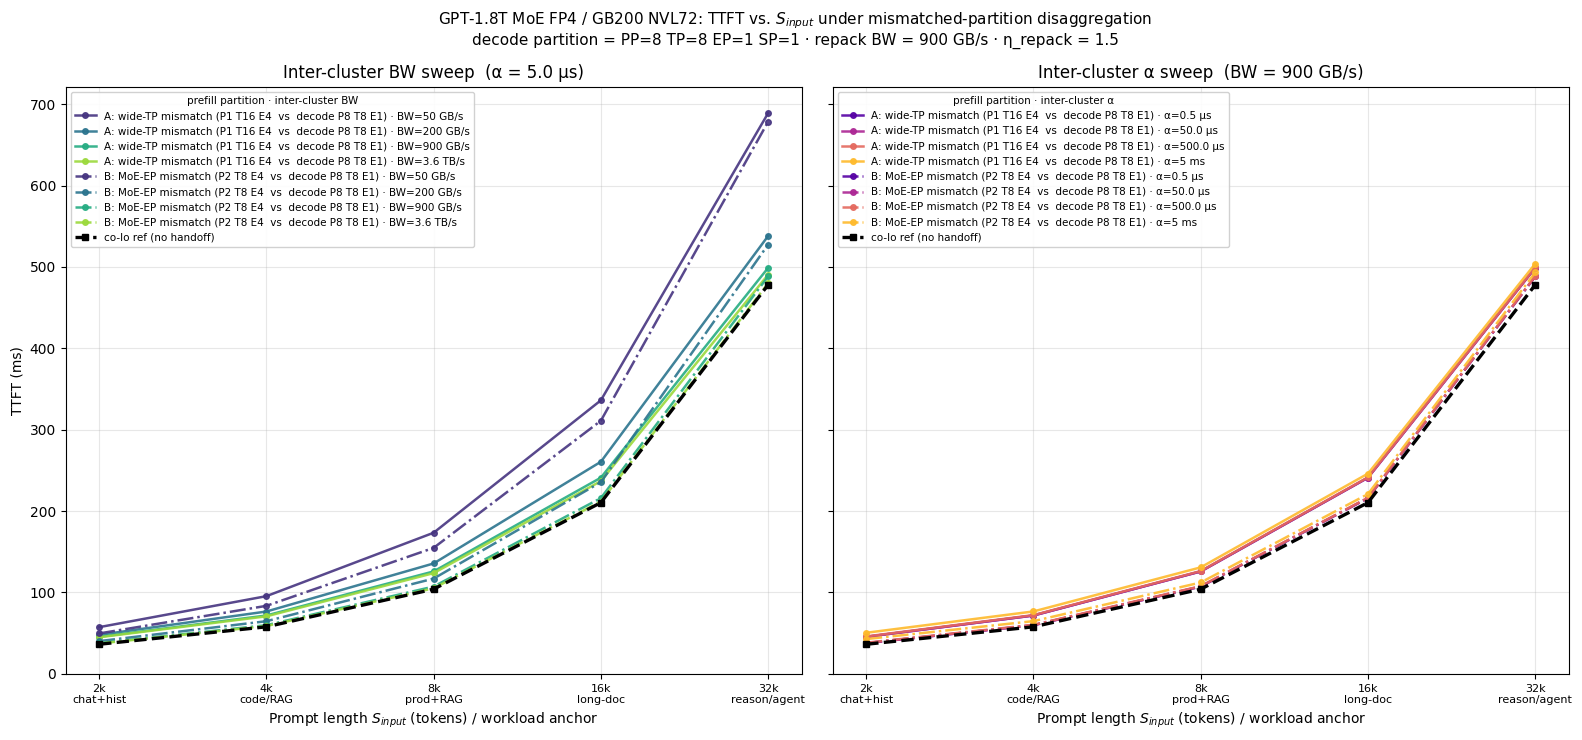

In [6]:
def fmt_s(S: int) -> str:
    return f"{S//1024}k" if S >= 1024 else str(S)


def apply_workload_xticks(ax):
    ax.set_xticks(S_INPUT_LIST)
    ax.set_xticklabels([f"{fmt_s(S)}\n{S_INPUT_TAGS[S]}" for S in S_INPUT_LIST],
                       fontsize=8)
    ax.minorticks_off()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

S_arr = np.array(S_INPUT_LIST)

# --- Panel 1: BW sweep --------------------------------------------------
cmap_bw = plt.get_cmap("viridis")
bw_colors = [cmap_bw(0.15 + 0.7 * i / max(1, len(BW_SWEEP_GBps) - 1))
             for i in range(len(BW_SWEEP_GBps))]

for si, sc in enumerate(SCENARIOS):
    if sc.is_colo:
        continue
    for bi, bw in enumerate(BW_SWEEP_GBps):
        y = np.array(bw_results[(si, bi)]) * 1e3
        bw_str = (f"{bw/1000:.1f} TB/s" if bw >= 1000 else f"{bw:.0f} GB/s")
        ax1.plot(S_arr, y, ls=sc.linestyle, color=bw_colors[bi], lw=1.8, alpha=0.9,
                 marker="o", ms=4,
                 label=f"{sc.short:s} · BW={bw_str}")

if colo_curve is not None:
    ax1.plot(S_arr, np.array(colo_curve) * 1e3, ls="--", color="black",
             lw=2.4, marker="s", ms=5, label="co-lo ref (no handoff)", zorder=6)

ax1.set_xscale("log")
ax1.set_yscale("linear")
ax1.set_ylim(bottom=0)
ax1.set_xlabel("Prompt length $S_{input}$ (tokens) / workload anchor")
ax1.set_ylabel("TTFT (ms)")
ax1.set_title(f"Inter-cluster BW sweep  (α = {ALPHA_FIXED_US:.1f} μs)")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc="upper left", fontsize=7.5, framealpha=0.9,
           title="prefill partition · inter-cluster BW",
           title_fontsize=7.5)
apply_workload_xticks(ax1)

# --- Panel 2: α sweep ---------------------------------------------------
cmap_al = plt.get_cmap("plasma")
al_colors = [cmap_al(0.15 + 0.7 * i / max(1, len(ALPHA_SWEEP_US) - 1))
             for i in range(len(ALPHA_SWEEP_US))]

for si, sc in enumerate(SCENARIOS):
    if sc.is_colo:
        continue
    for ai, al in enumerate(ALPHA_SWEEP_US):
        y = np.array(alpha_results[(si, ai)]) * 1e3
        al_str = (f"{al/1000:.0f} ms" if al >= 1000 else f"{al:.1f} μs")
        ax2.plot(S_arr, y, ls=sc.linestyle, color=al_colors[ai], lw=1.8, alpha=0.9,
                 marker="o", ms=4,
                 label=f"{sc.short:s} · α={al_str}")

if colo_curve is not None:
    ax2.plot(S_arr, np.array(colo_curve) * 1e3, ls="--", color="black",
             lw=2.4, marker="s", ms=5, label="co-lo ref (no handoff)", zorder=6)

ax2.set_xscale("log")
ax2.set_yscale("linear")
ax2.set_ylim(bottom=0)
ax2.set_xlabel("Prompt length $S_{input}$ (tokens) / workload anchor")
ax2.set_title(f"Inter-cluster α sweep  (BW = {BW_FIXED_GBps:.0f} GB/s)")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(loc="upper left", fontsize=7.5, framealpha=0.9,
           title="prefill partition · inter-cluster α",
           title_fontsize=7.5)
apply_workload_xticks(ax2)

fig.suptitle(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: TTFT vs. $S_{{input}}$ under mismatched-partition disaggregation\n"
    f"decode partition = PP=8 TP=8 EP=1 SP=1 · repack BW = {REPACK_BW_GBps:.0f} GB/s · η_repack = {REPACK_ETA}",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 6. Crossover table

For each (scenario, BW) pair, report the smallest `S_input` at which the disaggregated TTFT beats the co-lo baseline (i.e., the mismatched prefill's compute savings start to pay for its handoff). If the scenario never wins, mark it `—`.

In [7]:
assert colo_curve is not None
colo = np.array(colo_curve)

print(f"{'scenario':42s}  {'BW':>10s}  crossover S_input (first S where disagg ≤ co-lo)")
print("-" * 100)
for si, sc in enumerate(SCENARIOS):
    if sc.is_colo:
        continue
    for bi, bw in enumerate(BW_SWEEP_GBps):
        curve = np.array(bw_results[(si, bi)])
        wins = np.where(curve <= colo)[0]
        first_S = S_INPUT_LIST[wins[0]] if wins.size else None
        bw_str = (f"{bw/1000:.1f} TB/s" if bw >= 1000 else f"{bw:.0f} GB/s")
        if first_S is not None:
            first_S_str = f"{first_S:,}  ({S_INPUT_TAGS[first_S]})"
        else:
            first_S_str = "— (never wins in 2k–32k band)"
        print(f"  {sc.name:40s}  {bw_str:>10s}  {first_S_str}")

scenario                                            BW  crossover S_input (first S where disagg ≤ co-lo)
----------------------------------------------------------------------------------------------------
  mismatch A — wide-TP prefill (PP/TP/EP all differ from decode)     50 GB/s  — (never wins in 2k–32k band)
  mismatch A — wide-TP prefill (PP/TP/EP all differ from decode)    200 GB/s  — (never wins in 2k–32k band)
  mismatch A — wide-TP prefill (PP/TP/EP all differ from decode)    900 GB/s  — (never wins in 2k–32k band)
  mismatch A — wide-TP prefill (PP/TP/EP all differ from decode)    3.6 TB/s  — (never wins in 2k–32k band)
  mismatch B — MoE-EP prefill (PP+EP differ; TP matches decode)     50 GB/s  — (never wins in 2k–32k band)
  mismatch B — MoE-EP prefill (PP+EP differ; TP matches decode)    200 GB/s  — (never wins in 2k–32k band)
  mismatch B — MoE-EP prefill (PP+EP differ; TP matches decode)    900 GB/s  — (never wins in 2k–32k band)
  mismatch B — MoE-EP prefill (PP+EP diff

## 7. Takeaways

Focusing on the realistic commercial workload band (2k–32k), the story flips from the earlier wide-range sweep:

- **Mismatch doesn't pay off in the 2k–32k band — at any BW, at any α.** The compute savings from the mismatched prefill partitions are small:
  - **Mismatch A (wide-TP, all axes differ from decode)** is actually *slower* than co-lo for every `S_input < 32k` because its wide-TP collective tax outweighs its attention-FLOP savings until the prompt is long enough.
  - **Mismatch B (MoE-EP, TP matches decode)** saves only 0.4–8 ms vs. co-lo — it has nearly compute parity with the decode partition, so there's little to "win" with in the first place.
  Even at 3.6 TB/s inter-cluster BW, the KV handoff tax exceeds these savings everywhere in this range.
- **Co-lo is the right default for production workloads.** Splitwise's and DistServe's case for disaggregation rests on *different* benefits — decoupling prefill and decode scheduling, dedicating batch slots, improving goodput under mixed-SLA traffic — not on picking a faster prefill partition.
- **α is irrelevant.** Both panels show the α sweep essentially collapsing; M_KV in this band (0.6–10 GB) is large enough that transfer time dominates startup for all but the extreme 5 ms / cross-region case.
- **BW still matters — but as a floor, not a win condition.** Going from 50 GB/s to 3.6 TB/s closes the gap to co-lo substantially, but never crosses it in this band. The cross-cluster BW needed to make a mismatched prefill worth it *on latency grounds alone* sits out at `S_input ≥ 64k` (previously-verified earlier wide-range sweep).
- **What this study actually motivates**: the win case for mismatched-partition disagg is **long-context** (64k+) workloads (Mooncake's P99 territory). For the bulk of commercial traffic, matched-partition co-lo or disagg-for-scheduling (same partition, just separate clusters) is the simpler choice.
- **What to test next**: (a) `overlap_rho_KV > 0` with layer-wise streaming — can we hide handoff behind prefill compute? (b) wider decode partition (TP=16) to see whether the reshuffle cost drops. (c) throughput Pareto under mixed-request workloads where disagg's real benefit (goodput, not latency) shows up.